[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cyneuro/SCP/blob/main/6_analysis.ipynb)

# SCP Step 6 - Analysis

Analyze saved Step 5 outputs, compare runs or external curves, and generate optional figures/tables. This notebook is for post-processing; it does not rerun simulations.

Workflow:
- **6.0 Environment Setup**: configure local/Colab imports and dependencies.
- **6.1 Select Runs**: choose the cell, tune, saved run, comparison runs, and optional external curves.
- **6.2 Single Plot**: render the compact all-in-one single-run panel.
- **6.3 Output Plots**: plot output firing-rate/ISI curves for one run or comparisons.
- **6.4 Input Plots**: plot saved or summarized synaptic input activity.
- **6.5 Extra Analysis**: run metrics, synapse plots, tables, config comparisons, snapshots, and IClamp summaries.

Defaults are loaded from `modules/analysis/analysis_defaults.json` and the JSON presets in `modules/analysis/analysis_presets/`. The notebook cells expose common options; the JSON files expose the full option set.

Detailed guide: `docs/guides/analysis.md`.


## 6.0 Environment Setup

Run this first. In Colab, this cell can clone/install SCP; locally, it usually only finds the existing checkout and configures imports.

Quick guide:
- Leave `SCP_REPO_URL`, `SCP_REPO_BRANCH`, `SCP_REPO_DIR`, and `INSTALL_DEPS` unchanged for normal local use.
- In Colab, set `INSTALL_DEPS = True` if the runtime does not already have the required packages.
- Set the `SCP_*` environment variables only for private forks, alternate branches, or unusual Colab layouts.
- If imports fail locally, make sure this notebook is running from the SCP environment used for Steps 1-5.


In [1]:
# Environment setup: works locally or in Google Colab
%load_ext autoreload
%autoreload 2

import os
import subprocess
import sys
from pathlib import Path

# User-editable only when running in a fresh Colab or unusual local layout.
SCP_REPO_URL = os.environ.get("SCP_REPO_URL", "https://github.com/cyneuro/SCP.git")
SCP_REPO_BRANCH = os.environ.get("SCP_REPO_BRANCH", "") or None
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
AUTO_CLONE_REPO = os.environ.get("SCP_AUTO_CLONE", "1" if IN_COLAB else "0") not in {"0", "false", "False"}
INSTALL_DEPS = None  # None = install automatically in Colab, do not install locally.
SCP_REPO_DIR = Path(os.environ.get("SCP_REPO_DIR", "/content/SCP" if IN_COLAB else str(Path.cwd() / "SCP")))


def _looks_like_scp_repo(path: Path) -> bool:
    return (path / "modules").is_dir() and (path / "run_pipeline.py").is_file()


repo_root = None
env_root = os.environ.get("SCP_ROOT")
if env_root and _looks_like_scp_repo(Path(env_root).expanduser()):
    repo_root = Path(env_root).expanduser().resolve()
else:
    start = Path.cwd().resolve()
    candidates = list((start, *start.parents))
    for base in (start, start.parent):
        try:
            candidates.extend(child for child in base.iterdir() if child.is_dir())
        except Exception:
            pass
    for candidate in candidates:
        if _looks_like_scp_repo(candidate):
            repo_root = candidate.resolve()
            break

if repo_root is None:
    if not AUTO_CLONE_REPO:
        raise FileNotFoundError("Could not find SCP. Set SCP_ROOT or enable SCP_AUTO_CLONE=1.")
    clone_url = SCP_REPO_URL
    token = os.environ.get("SCP_GIT_TOKEN") or os.environ.get("SCP_GITHUB_TOKEN") or os.environ.get("GITHUB_TOKEN")
    if token and clone_url.startswith("https://") and "@" not in clone_url:
        clone_url = clone_url.replace("https://", f"https://{token}@", 1)
    clone_cmd = ["git", "clone", "--depth", "1"]
    if SCP_REPO_BRANCH:
        clone_cmd += ["--branch", SCP_REPO_BRANCH]
    clone_cmd += [clone_url, str(SCP_REPO_DIR)]
    subprocess.check_call(clone_cmd)
    repo_root = SCP_REPO_DIR.resolve()

os.environ["SCP_ROOT"] = str(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from modules.notebooks.bootstrap import ensure_notebook_dependencies, is_colab

ensure_notebook_dependencies(install_deps=INSTALL_DEPS)

print("Runtime:", "Colab" if is_colab() else "local")
print("SCP repo:", repo_root)


Runtime: local
SCP repo: /home/hrbncv/SCP


## 6.1 Select Runs

Choose the output tree and saved run(s) used by the rest of the notebook. Every downstream section reads this selection.

Quick guide:
- `cell_name`, `tunes_dir`, and `model_dir` select `cells/<CELL>/<tunes_dir>/<model_dir>/output_data`.
- `run_single_stem = "latest"` uses the newest saved run for single-run views.
- `run_compare_a` / `run_compare_b` are available for manual/non-widget compare calls.
- The widget UI provides the main run selector, compare-list selector, save toggles, and optional external compare paths.
- Compare paths can point to external CSV curves and can include shift/scale/style metadata, such as `external_data/pyrFiringRateAvg.csv@290;color=k;label=PN_bio`.

Recommended use: start with `latest`, verify the single run, then add comparison runs or external curves only when needed.


In [2]:
# User-facing defaults for manual/non-widget use
cell_name = "SST"      # bundled examples: "PV" or "SST"
tunes_dir = "tunes"
model_dir = "tuned"

run_single_stem = "latest"
run_compare_a = "latest"
run_compare_b = "previous"  # use "none" to disable comparison
compare_a_path = ""
compare_b_path = ""

output_metrics_std_mode = "std"  # "std" or "sem" for output metric spread


In [3]:
# Load analysis defaults, presets, imports, and optional widgets
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from modules import run_sim
from modules.analysis import analysis, analysis_ui, plotting

_defaults_path = repo_root / "modules" / "analysis" / "analysis_defaults.json"
_defaults = json.loads(_defaults_path.read_text())

for _preset_key in (
    "output_plot_preset_path",
    "input_plot_preset_path",
    "output_metrics_preset_path",
    "extra_preset_path",
):
    _preset_raw = _defaults.get(_preset_key)
    if not _preset_raw:
        continue
    _preset_path = Path(str(_preset_raw)).expanduser()
    if not _preset_path.is_absolute():
        _preset_path = repo_root / _preset_path
    if not _preset_path.is_file():
        print(f"Preset not found ({_preset_key}): {_preset_path}")
        continue
    _preset_payload = json.loads(_preset_path.read_text())
    if not isinstance(_preset_payload, dict):
        continue
    _preset_defaults = _preset_payload.get("defaults", _preset_payload)
    if isinstance(_preset_defaults, dict):
        _defaults.update(_preset_defaults)

for _k in ("plot_window", "input_plot_window", "y_window"):
    if isinstance(_defaults.get(_k), list) and len(_defaults[_k]) == 2:
        _defaults[_k] = (_defaults[_k][0], _defaults[_k][1])

globals().update(_defaults)

BASE_DIR = repo_root
CELLS_DIR = BASE_DIR / "cells"

use_widgets = True
try:
    import ipywidgets as widgets
    from IPython.display import display
    _HAVE_WIDGETS = True
except Exception:
    _HAVE_WIDGETS = False


--No graphics will be displayed.


In [4]:
# Selection UI
analysis_ui.build_selection_ui(globals())

# (optional) quick selection check
# analysis_ui.get_selection_from_globals(globals())

Textarea(value='external_data/pyrFiringRateAvg.csv@290.0;color=k;label=PN_bio;linestyle=--', description='Comp…

Output()

## 6.2 Single Plot

Use this section for the compact all-in-one plot for one saved Step 5 run. It is the best first check after a simulation because it can combine output rate, Vm, output raster, input rate, and input raster in one figure.

Quick guide:
- Leave values as `None` or empty lists to use `modules/analysis/analysis_presets/single_plot.json`.
- Set `single_plot_trial_idx` to choose the saved trial used for Vm/raster panels.
- Use `single_plot_window` to crop the x-axis, or leave it `None` to auto-window around the stimulus when available.
- `single_plot_include_input_raster` and `single_plot_include_output_raster` control raster panels.
- `single_plot_top_input_groups` and `single_plot_raster_input_groups` can restrict input panels to selected synapse groups.
- `single_plot_display_options` only changes notebook display size; it does not change the saved figure.

Full defaults and advanced styling options live in `modules/analysis/analysis_presets/single_plot.json`.


In [5]:
# Single-plot options
# Leave values as None to use modules/analysis/analysis_presets/single_plot.json.

single_plot_preset_path = None      # None -> default preset JSON
single_plot_run = None              # None -> current Selection UI choice; otherwise use a run stem/path
single_plot_prefer_saved = True     # Reuse saved single_plot files when present and overwrite is disabled
single_plot_save = False             # If False, display/regenerate without writing new plot files
single_plot_display_options = {
    "width": 750,                   # Notebook preview width in pixels; export size is unchanged
    "height": None,
}
single_plot_display_options = {
    key: value for key, value in single_plot_display_options.items() if value is not None
}

single_plot_overrides = {
    "trial_idx": None,
    "top_input_groups": None,          # e.g. ["pn_exc", "vip_inh"]
    "raster_input_groups": None,       # e.g. ["pn_exc"]
    "include_input_raster": None,
    "include_output_raster": None,
    "input_source": None,              # "auto", "saved", or "stats"
    "output_mode": None,               # "raw" or "normalized"
    "output_band_mode": None,          # None, "std", or "sem"
    "plot_window": None,               # e.g. (200, 1100)
    "auto_plot_window_from_stim": None,
    "plot_window_adjustment_ms": None,
    "show_panel_titles": None,
    "figsize": None,                   # e.g. (6, 6)
}

single_plot_overrides = {
    key: value for key, value in single_plot_overrides.items() if value is not None
}


Using saved single plot (no regeneration):
  /home/hrbncv/SCP/cells/SST/tunes/tuned/output_data/notebook_single_trial/plots/single_plot.svg
  /home/hrbncv/SCP/cells/SST/tunes/tuned/output_data/notebook_single_trial/plots/single_plot.png


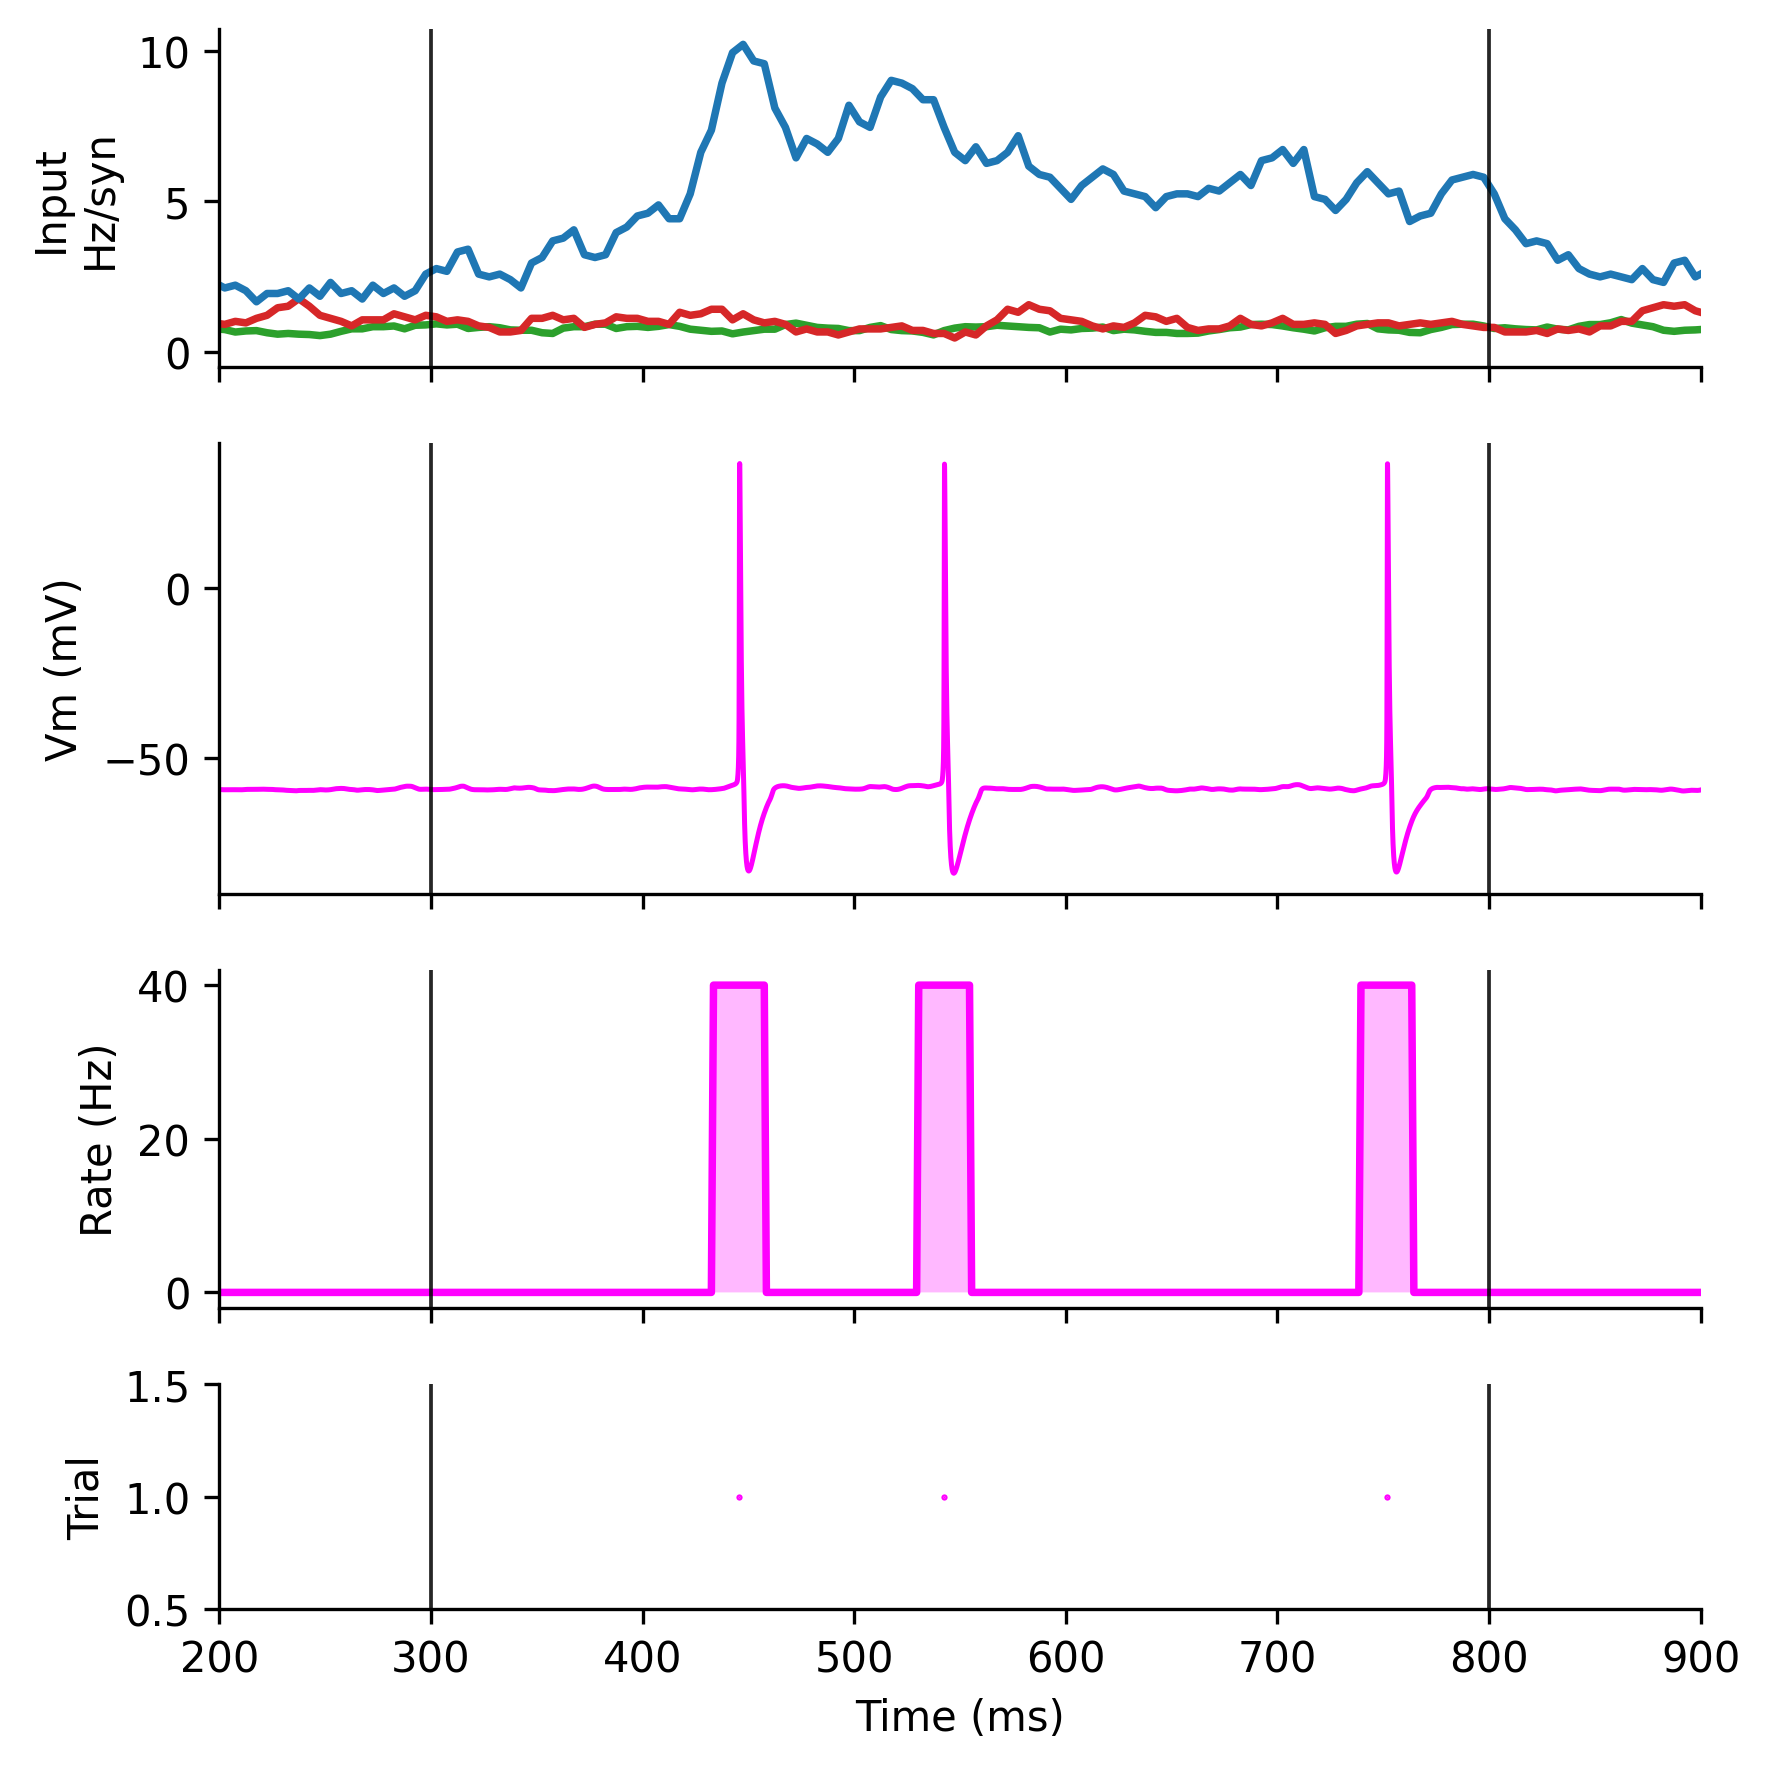

PosixPath('/home/hrbncv/SCP/cells/SST/tunes/tuned/output_data/notebook_single_trial/plots/single_plot.png')

In [6]:
# Paper-ready composite panel (single panel)
from modules.analysis import single_plot_panel

sel_single_plot = analysis_ui.get_selection_from_globals(globals())
if single_plot_run not in (None, "", "selection"):
    sel_single_plot = dict(sel_single_plot)
    sel_single_plot["run_single"] = single_plot_run
    sel_single_plot["compare_list"] = []

single_plot_panel_result = single_plot_panel.run_single_plot_from_selection(
    sel_single_plot,
    repo_root=repo_root,
    preset_path=single_plot_preset_path,
    preset_overrides=single_plot_overrides,
    prefer_saved_export=single_plot_prefer_saved,
    allow_export=single_plot_save,
)

single_plot_panel.display_single_plot_result(single_plot_panel_result, **single_plot_display_options)


## 6.3 Output Plots

Use this section for output firing-rate and ISI plots across one run, two runs, a compare list, and/or external curves. This is the main UI for comparing model output shapes.

Quick guide:
- **Run** controls whether to draw the compact rate/ISI curve, full saved-output plot, raster, and spike stats.
- **Window** controls x/y limits, stimulus markers, auto-windowing around the stimulus, and zero-origin display.
- **Curve** controls raw vs normalized output, rate vs ISI vs stacked plots, binning/smoothing, and normalization mode.
- **Compare** controls overlay/side-by-side/stacked layouts and optional std/sem shading.
- **Export** can save plotted data to CSV; leave the path blank for an automatic output path.

Defaults live in `modules/analysis/analysis_presets/output_plotting.json`; metric definitions used by the output overlays live in `modules/analysis/analysis_presets/output_metrics.json`.


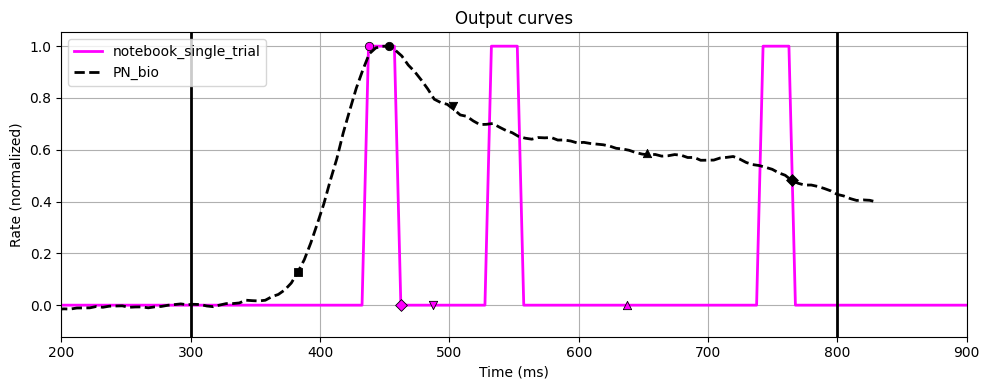

In [7]:
# Outputs UI (single or compare)
analysis_ui.build_outputs_ui(globals())


## 6.4 Input Plots

Use this section for synaptic input summaries, input rasters, and input comparisons. It is intended for checking what presynaptic activity was delivered to the model.

Quick guide:
- **Run** chooses input source mode (`auto`, saved inputs, or saved stats), mean traces, rasters, and trial/group filters.
- **Window** controls x-axis cropping and stimulus markers.
- **Curve** controls binning, smoothing, std/sem display, and line styling.
- **Raster** controls trial index, max displayed trains, and dot/line raster style.
- **Compare/Export** controls compare layout and plotted-data CSV export.

Defaults live in `modules/analysis/analysis_presets/input_plotting.json`. If a run does not contain saved input details, the UI falls back where possible and reports what is missing.


In [8]:
# Inputs UI (single or compare)
analysis_ui.build_inputs_ui(globals())


NameError: name 'analysis' is not defined

## 6.5 Extra Analysis

Use this section for optional analysis utilities that do not belong in the core single/output/input plotting path. These tools are useful after the basic plots look correct.

Available modes:
- **Output metrics (table)**: compute rate-curve metrics and optional metric-distribution plots.
- **Compare configs (restore-style)**: compare config values across selected runs and the current tune.
- **Input sampling (preview)**: sample generated input curves from synapse configs without rerunning a full simulation.
- **Synapse plots**: summarize and plot saved synapse records from Step 5 outputs. Requires runs saved with synapse records.
- **Snapshot compare**: compare saved run snapshots/manifests for debugging reproducibility.
- **Single-run tables**: summarize cell sections, geometry, synapses, recordings, and total synaptic traces when saved/available.
- **IClamp analysis**: summarize current-injection runs. Skips non-`iclamp` outputs.

Defaults live in `modules/analysis/analysis_presets/extra_analysis.json`. Some modes are data-dependent and will print a skip message if the selected run does not contain the needed saved records.


In [ ]:
# Extra analysis UI
analysis_ui.get_selection_from_globals(globals())
analysis_ui.build_extra_ui(globals())
